In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
)

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

from tensorflow.keras.datasets import cifar10

from sklearn.preprocessing import OneHotEncoder

## CNN in MNIST Data

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

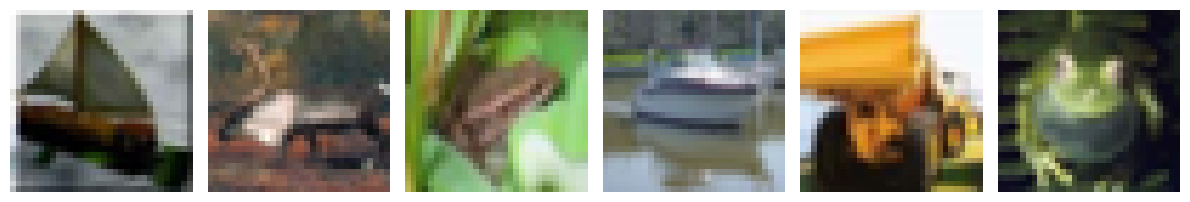

In [3]:
indices = np.random.choice(len(X_train), 6, replace= False)
selected_images = [X_train[i] for i in indices]

fig, axes = plt.subplots(1, 6, figsize=(12, 4))

for ax, img, in zip(axes, selected_images):
    ax.imshow(img, cmap="gray")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# min-max scaling
X_train = X_train / 255
X_test = X_test / 255

In [5]:
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train = one_hot_encoder.fit_transform(y_train.reshape(-1, 1))
y_test = one_hot_encoder.transform(y_test.reshape(-1, 1))

## Model Defination

In [6]:
input_shape = X_train.shape[1:]
input_shape

(32, 32, 3)

In [7]:

input_layer = Input(shape=input_shape)

model = Sequential([
    input_layer,

    Conv2D(filters=6, kernel_size=(5, 5), strides=(1, 1), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(filters=16, kernel_size=(5, 5), strides=(1, 1), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Flatten(),

    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(50, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,532 (189.58 KB)

 Trainable params: 48,532 (189.58 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1,
    shuffle=True
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.2932 - loss: 1.8821 - val_accuracy: 0.4174 - val_loss: 1.5904
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4153 - loss: 1.5870 - val_accuracy: 0.4458 - val_loss: 1.5030
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4575 - loss: 1.4907 - val_accuracy: 0.4988 - val_loss: 1.3884
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4807 - loss: 1.4293 - val_accuracy: 0.5135 - val_loss: 1.3325
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4987 - loss: 1.3857 - val_accuracy: 0.5351 - val_loss: 1.2850
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5103 - loss: 1.3576 - val_accuracy: 0.5159 - val_loss: 1.3660
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5260 - loss: 1.3228 - val_accuracy: 0.5406 - val_loss: 1.2821
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5343 - loss: 1.2983 - val_accu

In [10]:
df = pd.DataFrame(history.history)

<Axes: title={'center': 'Loss vs. Validation Loss'}>

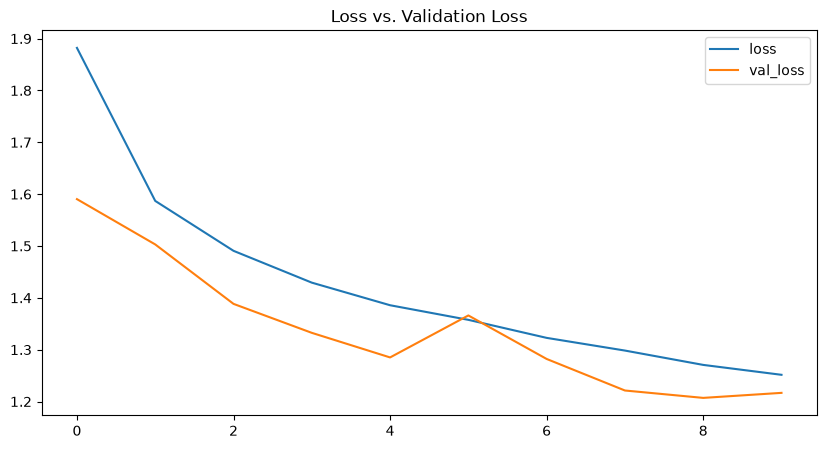

In [11]:
df[['loss', 'val_loss']].plot(title='Loss vs. Validation Loss', figsize=(10, 5))

In [12]:
y_pred = np.argmax(model.predict(X_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


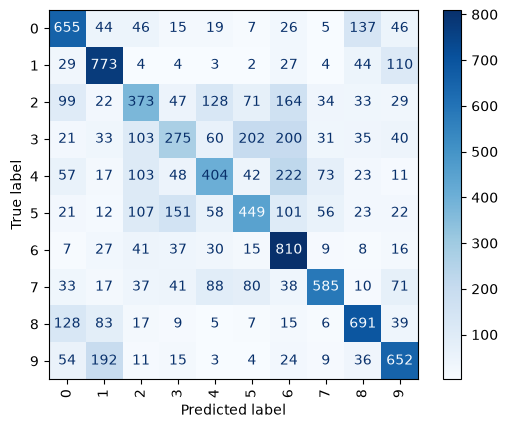

In [13]:
ConfusionMatrixDisplay(confusion_matrix(y_test.argmax(axis=1), y_pred)).plot(cmap='Blues', xticks_rotation='vertical')

In [14]:
accuracy = accuracy_score(y_test.argmax(axis=1), y_pred)
recall = recall_score(y_test.argmax(axis=1), y_pred, average='macro')
precision = precision_score(y_test.argmax(axis=1), y_pred, average='macro')
f1 = f1_score(y_test.argmax(axis=1), y_pred, average='macro')

In [15]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.5667
Recall: 0.5667
Precision: 0.5627
F1 Score: 0.5567
